In [7]:
import pandas as pd
from sklearn import linear_model, neighbors, pipeline, metrics, dummy, preprocessing, model_selection
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("studenti2.csv")
df[['absences']].describe()

,absences
count,395.000000
mean,5.708861
std,8.003096
min,0.000000
25%,0.000000
50%,4.000000
75%,8.000000
max,75.000000


In [5]:
features = df[df.columns[:-1]]
target = df[df.columns[-1]]

In [8]:
def rms_error(y_true, y_pred):
    return np.sqrt(metrics.mean_squared_error(y_true, y_pred))

In [9]:
scaler = preprocessing.StandardScaler()
lr = linear_model.LinearRegression()
knn_3 = neighbors.KNeighborsRegressor(n_neighbors=3)
knn_10 = neighbors.KNeighborsRegressor(n_neighbors=10)

std_lr_pipe = pipeline.make_pipeline(scaler, lr)
std_knn_3_pipe = pipeline.make_pipeline(scaler, knn_3)
std_knn_10_pipe = pipeline.make_pipeline(scaler, knn_10)

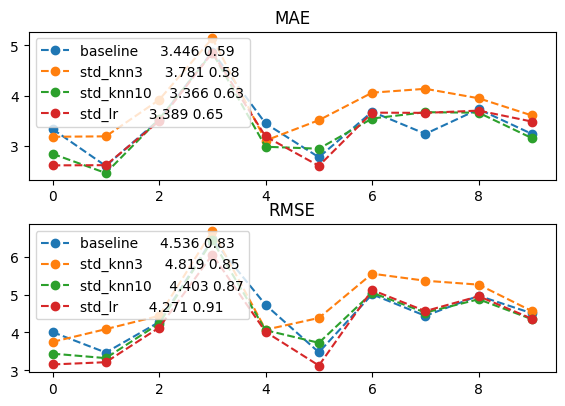

In [10]:
regressors = {'baseline'  : dummy.DummyRegressor(strategy='mean'),
              'std_knn3'  : std_knn_3_pipe,
              'std_knn10' : std_knn_10_pipe,
              'std_lr'    : std_lr_pipe}
msrs = {'MAE'  : metrics.make_scorer(metrics.mean_absolute_error),
        'RMSE' : metrics.make_scorer(rms_error)}
fig, axes = plt.subplots(2, 1, figsize=(6,4))
fig.tight_layout()
for mod_name, model in regressors.items():
    cv_results = model_selection.cross_validate(model,features, target, scoring = msrs, cv=10)
    for ax, msr in zip(axes, msrs):
        msr_results = cv_results["test_" + msr]
        my_lbl = "{:12s} {:.3f} {:.2f}".format(mod_name,
                                               msr_results.mean(),
                                               msr_results.std())
        ax.plot(msr_results, 'o--', label=my_lbl)
        ax.set_title(msr)
        ax.legend()

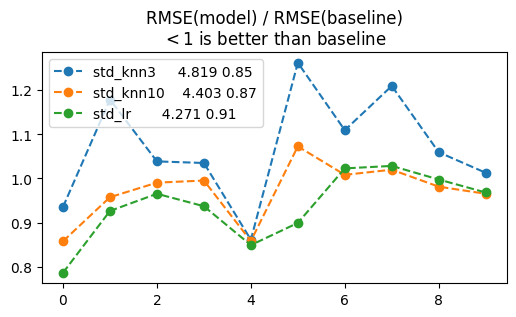

In [13]:
fig,ax = plt.subplots(1,1,figsize=(6,3))
baseline_results = model_selection.cross_val_score(regressors['baseline'], features, target, scoring = msrs['RMSE'], cv=10)

for mod_name, model in regressors.items():
    if mod_name.startswith("std_"):
        cv_results = model_selection.cross_val_score(model, features, target, scoring = msrs['RMSE'], cv=10)

        my_lbl = "{:12s} {:.3f} {:.2f}".format(mod_name, cv_results.mean(), cv_results.std())

        ax.plot(cv_results / baseline_results, 'o--', label=my_lbl)
ax.set_title("RMSE(model) / RMSE(baseline)\n$<1$ is better than baseline")
ax.legend();

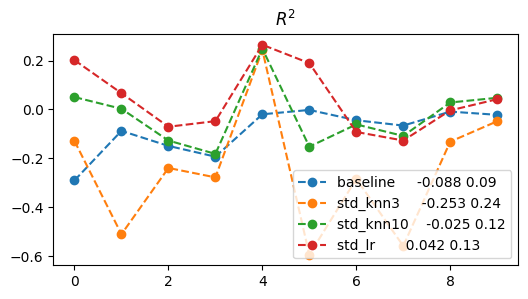

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6,3))
for mod_name, model in regressors.items():
        cv_results = model_selection.cross_val_score(model, features, target, cv=10)
        my_lbl = "{:12s} {:.3f} {:.2f}".format(mod_name, cv_results.mean(), cv_results.std())

        ax.plot(cv_results, 'o--', label=my_lbl)
ax.set_title("$R^2$")
ax.legend()